In [70]:
pip install pandas numpy scikit-learn plotly seaborn matplotlib

In [72]:
import pandas as pd
import numpy as np

import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [74]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Churn Prediction.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [78]:
df = df.drop("customerID", axis=1)

In [80]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df = df.dropna()

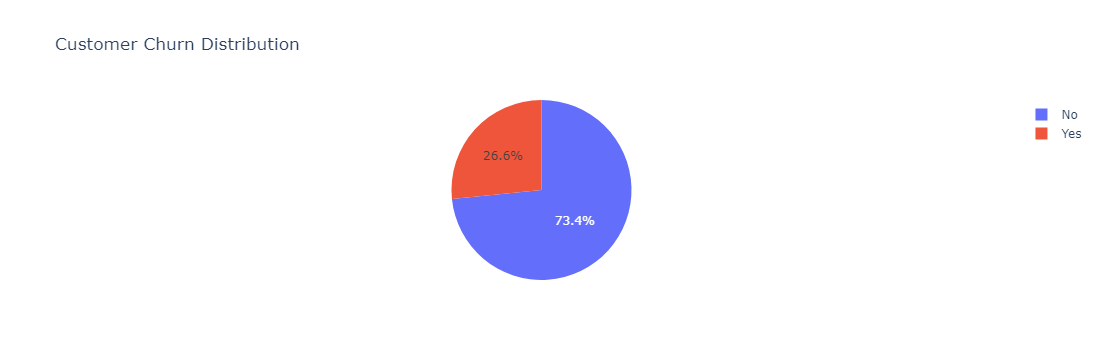

In [82]:
fig = px.pie(
    df,
    names="Churn",
    title="Customer Churn Distribution"
)

fig.show()

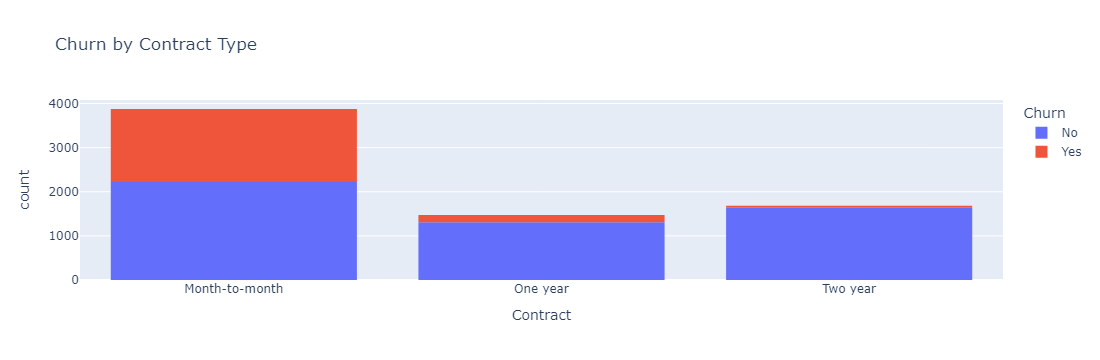

In [84]:
fig = px.histogram(
    df,
    x="Contract",
    color="Churn",
    title="Churn by Contract Type"
)

fig.show()

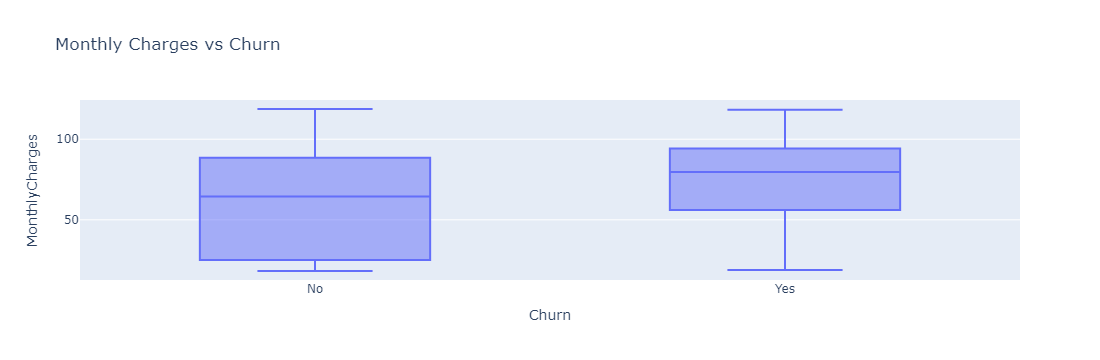

In [86]:
fig = px.box(
    df,
    x="Churn",
    y="MonthlyCharges",
    title="Monthly Charges vs Churn"
)

fig.show()

In [88]:
df = pd.get_dummies(df, drop_first=True)

In [90]:
X = df.drop("Churn_Yes", axis=1)

y = df["Churn_Yes"]

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [94]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [96]:
predictions = model.predict(X_test)

In [98]:
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.7853589196872779


In [100]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1033
        True       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



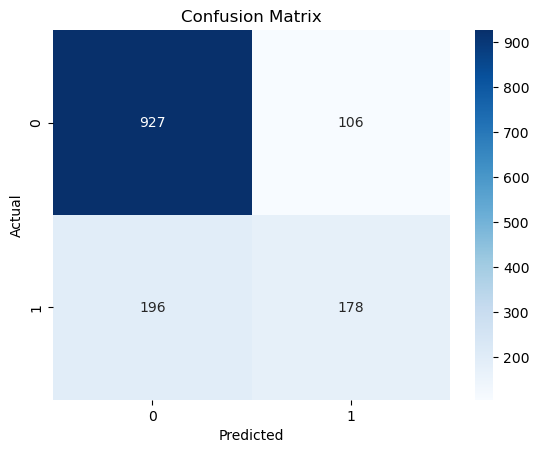

In [102]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [104]:
importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

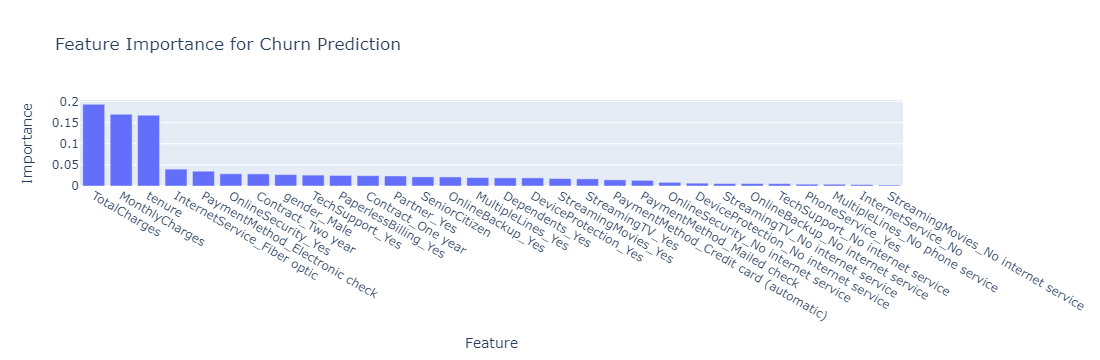

In [106]:
fig = px.bar(
    importance_df,
    x="Feature",
    y="Importance",
    title="Feature Importance for Churn Prediction"
)

fig.show()

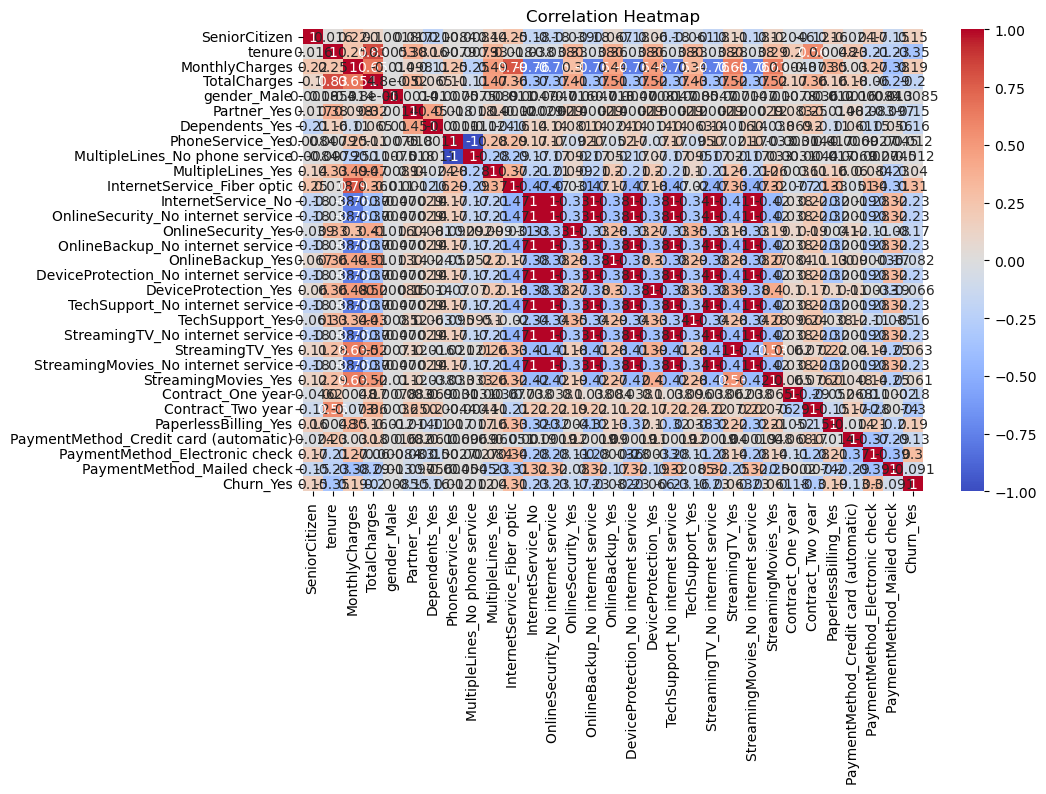

In [110]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [112]:
df = pd.get_dummies(df, drop_first=True)

In [114]:
X = df.drop("Churn_Yes", axis=1)

y = df["Churn_Yes"]

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [122]:
from sklearn.linear_model import LogisticRegression

In [124]:
import pandas as pd
import numpy as np

import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [126]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7874911158493249


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [128]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7213930348258707


In [130]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7825159914712153


In [132]:
models = ["Logistic Regression","Decision Tree","Random Forest"]

scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

comparison = pd.DataFrame({
    "Model":models,
    "Accuracy":scores
})

comparison

,Model,Accuracy
0,Logistic Regression,0.787491
1,Decision Tree,0.721393
2,Random Forest,0.782516


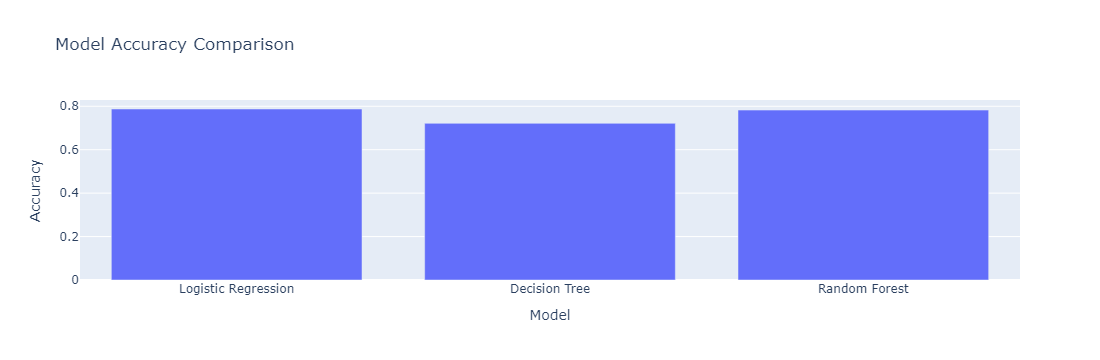

In [134]:
px.bar(comparison, x="Model", y="Accuracy", title="Model Accuracy Comparison")

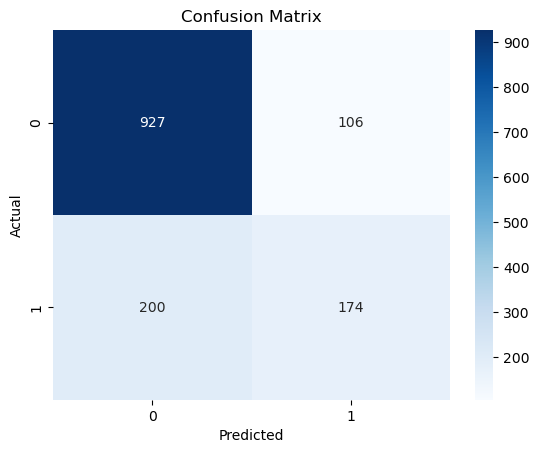

In [136]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

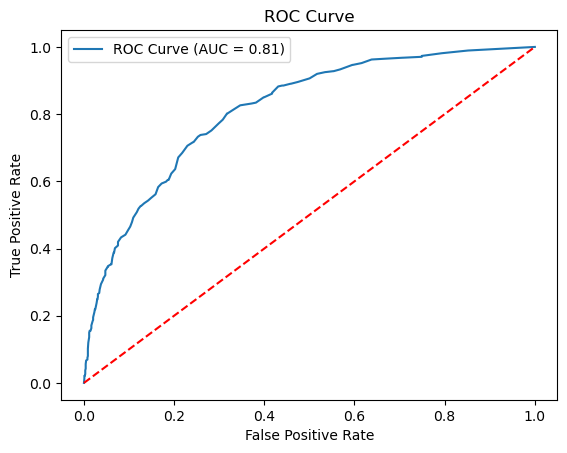

In [138]:
rf_probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [140]:
importance = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature":X.columns,
    "Importance":importance
}).sort_values("Importance", ascending=False)

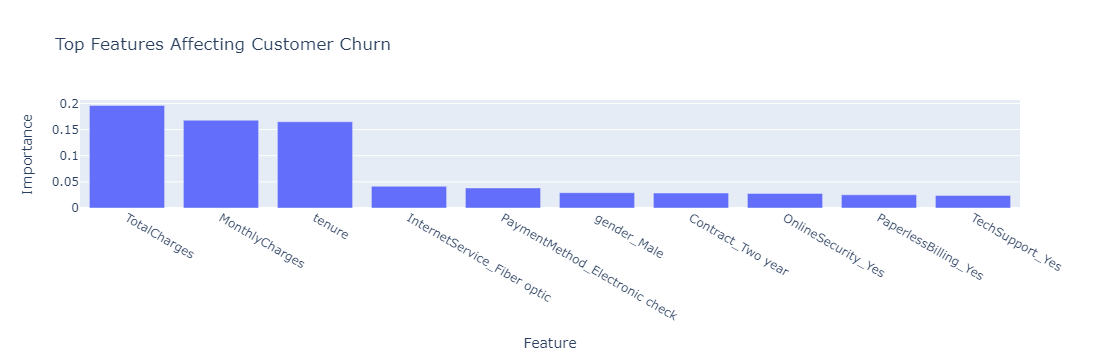

In [142]:
px.bar(
    importance_df.head(10),
    x="Feature",
    y="Importance",
    title="Top Features Affecting Customer Churn"
)

In [144]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.787491
1,Decision Tree,0.721393
2,Random Forest,0.782516


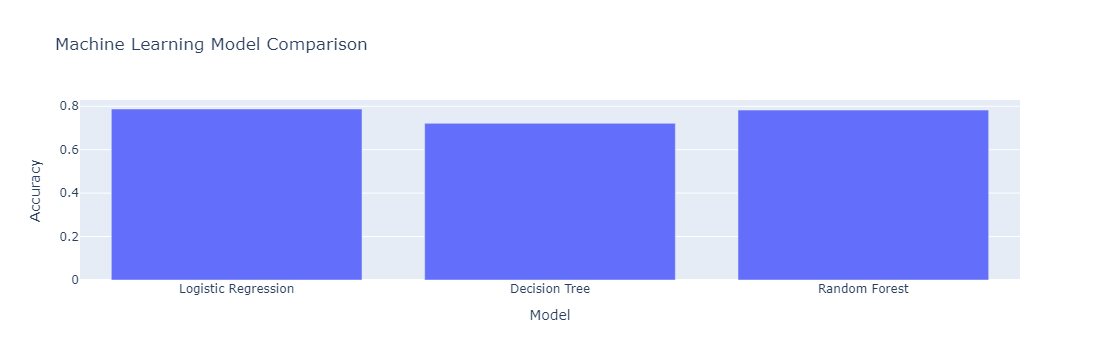

In [146]:
import plotly.express as px

fig = px.bar(
    comparison,
    x="Model",
    y="Accuracy",
    title="Machine Learning Model Comparison"
)

fig.show()

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [152]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define model
rf = RandomForestClassifier()

# Define parameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}

# GridSearch
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [153]:
best_model = grid_search.best_estimator_

In [154]:
pred = best_model.predict(X_test)

In [158]:
from sklearn.metrics import accuracy_score

print("Tuned Model Accuracy:", accuracy_score(y_test, pred))

Tuned Model Accuracy: 0.7953091684434968


In [160]:
grid_search.best_params_
grid_search.best_score_

0.8037333333333333

In [167]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [170]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

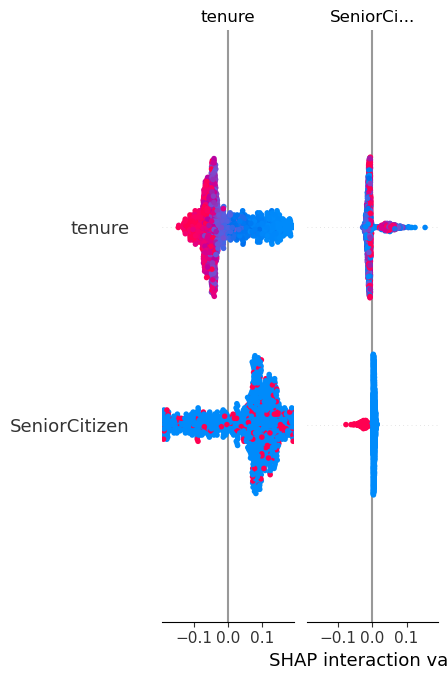

In [175]:
shap.summary_plot(shap_values, X_test)

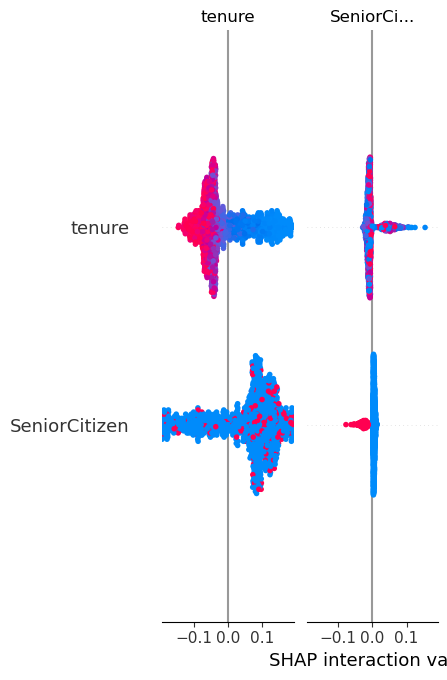

In [179]:
shap.summary_plot(shap_values, X_test)

In [190]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
